In [1]:
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display


import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 20260908
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")  # force CPU for reproducibility

print("PyTorch:", torch.__version__)
print("Device:", device)


PyTorch: 2.13.0+cu132
Device: cuda


# GAMEX Practical 1 — Autoregressive Transformers for Edinburgh Airport Arrivals

**Edinburgh Summer School on Generative AI for Extremes — 8 September 2026**  
**Suggested time:** 60 minutes

This notebook uses a **synthetic arrival-trajectory dataset contextualised to Edinburgh Airport**.

Edinburgh Airport has one physical runway, **06/24**. For this teaching example:

- **Runway 06:** arrivals approach from the west / south-west toward approximately 60° (East-Northeast)
- **Runway 24:** arrivals approach from the east / north-east toward approximately 240° (West-Southwest)
- Aircraft take off and land into the wind to generate optimal lift. Due to Scotland’s prevailing westerly winds, Runway 24 is the one active the majority of the time.

The trajectories are **not real ADS-B tracks and do not reproduce Edinburgh's published arrival procedures**. They are generated locally so that the practical remains reliable and offline.

The simulator captures one realistic qualitative feature:

> aircraft may be spread out and curved farther from the airport, but they progressively converge onto a common final approach before reaching the runway.




| Edinburgh Airpot Runway Path <br> (Google Maps) | Arrivals on 7th Sep 2026, 11:00am-11:04am <br> (Flightradar) |
| :---: | :---: |
| <img src="figures/Edinburgh_airport_runway_num.png" alt="Runway Path" width="650"> | <img src="figures/Edinburgh_Airport_Arrival_Flightradar_speedup.gif" alt="Flightradar Arrivals" width="650"> |

## Learning goals

By the end you should be able to:

- convert continuous trajectory positions into discrete airspace tokens;
- construct shifted input/target sequences;
- explain the role of a causal mask;
- implement a small Transformer with PyTorch;
- train using next-token negative log-likelihood;
- condition generation on Runway 06 versus Runway 24;
- generate complete trajectories autoregressively;
- continue a partially observed arrival;
- investigate temperature and top-k sampling;
- evaluate trajectory smoothness rather than judging samples only by appearance.


## 1. Generate synthetic Edinburgh arrivals

The code below uses a local East/North coordinate system centred on the runway.

The route geometry is deliberately simple:

1. aircraft enter the outer plotting region with a continuous range of lateral offsets;
2. a smooth vectoring-like curve moves them towards the extended runway centreline;
3. the final 9–14 km of the toy simulation becomes progressively straighter;
4. the trajectory finishes at the appropriate runway threshold.

There are **no artificial upper and lower lanes**.


In [2]:
# -------------------------------------------------------------------
# Synthetic Edinburgh Airport arrival simulator
# -------------------------------------------------------------------
#
# Real context used:
#   * Edinburgh has one physical runway, 06/24.
#   * Runway 06 arrivals approach from the west / south-west.
#   * Runway 24 arrivals approach from the east / north-east.
#
# Teaching assumptions:
#   * We generate simplified radar-vectoring-like turns onto final.
#   * These are NOT real ADS-B tracks, STARs, ILS procedures or ATC clearances.
#   * The simulator is designed only to create a realistic-looking
#     distribution for learning generative modelling.
#
# Local coordinate system:
#   x = East (km)
#   y = North (km)
#   airport/runway centre = (0, 0)

N_WAYPOINTS = 30
RUNWAY_LENGTH_KM = 2.56
HALF_RUNWAY_KM = RUNWAY_LENGTH_KM / 2

HEADING_06 = 60.0
HEADING_24 = 240.0

P_RUNWAY_24 = 0.85

AIRSPACE_XLIM = (-40.0, 40.0)
AIRSPACE_YLIM = (-30.0, 30.0)

def heading_vector(deg):
    rad = math.radians(deg)
    return torch.tensor(
        [math.sin(rad), math.cos(rad)],
        dtype=torch.float32,
    )

D06 = heading_vector(HEADING_06)
D24 = heading_vector(HEADING_24)

CROSS = torch.tensor([D06[1], -D06[0]])

THRESHOLD_06 = -HALF_RUNWAY_KM * D06
THRESHOLD_24 = +HALF_RUNWAY_KM * D06

def smoothstep(q):
    q = torch.clamp(q, 0.0, 1.0)
    return q * q * (3.0 - 2.0 * q)

def make_edinburgh_arrivals(
    n_flights=4000,
    n_waypoints=N_WAYPOINTS,
    seed=SEED,
):
    g = torch.Generator().manual_seed(seed)

    trajectories = []
    runway_labels = []
    altitudes = []

    for _ in range(n_flights):
        runway = int(
            (torch.rand((), generator=g) < P_RUNWAY_24).item()
        )

        if runway == 0:
            heading = D06
            threshold = THRESHOLD_06
        else:
            heading = D24
            threshold = THRESHOLD_24

        start_distance = 28.0 + 10.0 * torch.rand((), generator=g)
        intercept_distance = 9.0 + 5.0 * torch.rand((), generator=g)

        initial_cross_track = 6.0 * torch.randn((), generator=g)
        vectoring_bend = 2.2 * torch.randn((), generator=g)
        intercept_cross_track = 0.35 * torch.randn((), generator=g)
        touchdown_cross_track = 0.05 * torch.randn((), generator=g)

        distance_to_threshold = torch.linspace(
            start_distance.item(),
            0.0,
            n_waypoints,
        )

        cross_track = torch.zeros(n_waypoints)

        for j, d in enumerate(distance_to_threshold):
            if d > intercept_distance:
                q = (d - intercept_distance) / (
                    start_distance - intercept_distance
                )
                q = torch.clamp(q, 0.0, 1.0)

                cross_track[j] = (
                    intercept_cross_track
                    + (initial_cross_track - intercept_cross_track)
                    * smoothstep(q)
                    + vectoring_bend * torch.sin(math.pi * q)
                )
            else:
                q = d / intercept_distance
                cross_track[j] = (
                    touchdown_cross_track
                    + (intercept_cross_track - touchdown_cross_track) * q
                )

        envelope = (distance_to_threshold / start_distance) ** 1.5
        cross_track += (
            0.12
            * torch.randn(n_waypoints, generator=g)
            * envelope
        )

        xy = (
            threshold[None, :]
            - distance_to_threshold[:, None] * heading[None, :]
            + cross_track[:, None] * CROSS[None, :]
        )

        xy[-1] = threshold + touchdown_cross_track * CROSS

        altitude = (
            0.06
            + 0.055 * distance_to_threshold
            + 0.05
            * torch.randn(n_waypoints, generator=g)
            * envelope
        )
        altitude = torch.clamp(altitude, min=0.05)

        trajectories.append(xy)
        runway_labels.append(runway)
        altitudes.append(altitude)

    return (
        torch.stack(trajectories),
        torch.tensor(runway_labels).long(),
        torch.stack(altitudes),
    )

def draw_edinburgh_runway(ax=None, show_extended_final=False):
    if ax is None:
        ax = plt.gca()

    a = -HALF_RUNWAY_KM * D06
    b = +HALF_RUNWAY_KM * D06

    ax.plot(
        [a[0], b[0]],
        [a[1], b[1]],
        linewidth=6,
        solid_capstyle="butt",
        label="Edinburgh Airport Runway",
    )

    ax.scatter(
        [THRESHOLD_06[0], THRESHOLD_24[0]],
        [THRESHOLD_06[1], THRESHOLD_24[1]],
        marker="|",
        s=140
    )

    if show_extended_final:
        for threshold, heading in [
            (THRESHOLD_06, D06),
            (THRESHOLD_24, D24),
        ]:
            outer = threshold - 15.0 * heading
            ax.plot(
                [threshold[0], outer[0]],
                [threshold[1], outer[1]],
                linestyle="--",
                linewidth=1, color = "steelblue"
            )

def project_to_runway_coordinates(xy, runway_value):
    if runway_value == 0:
        heading = D06
        threshold = THRESHOLD_06
    else:
        heading = D24
        threshold = THRESHOLD_24

    relative = xy - threshold
    distance_to_threshold = -(relative @ heading)
    cross_track = relative @ CROSS

    return distance_to_threshold, cross_track

trajectories, runway, altitude = make_edinburgh_arrivals()

print("Dataset:", tuple(trajectories.shape))
print("RWY 06 flights:", int((runway == 0).sum()))
print("RWY 24 flights:", int((runway == 1).sum()))
print("RWY 24 fraction:", round((runway == 1).float().mean().item(), 3))


Dataset: (4000, 30, 2)
RWY 06 flights: 603
RWY 24 flights: 3397
RWY 24 fraction: 0.849


### Edinburgh context used in the simulator

Only broad airport facts are used:

- runway designation **06/24**;
- opposite arrival directions;
- a longer-run tendency to use Runway 24 more often.

The vectoring curves themselves are synthetic teaching constructs.

Official background:
- https://www.edinburghairport.com/inside-edi/all-about-edi/one-runway-but-two-directions-why-does-edinburgh-airports-arrival-and
- https://corporate.edinburghairport.com/about-us/facts-and-figures


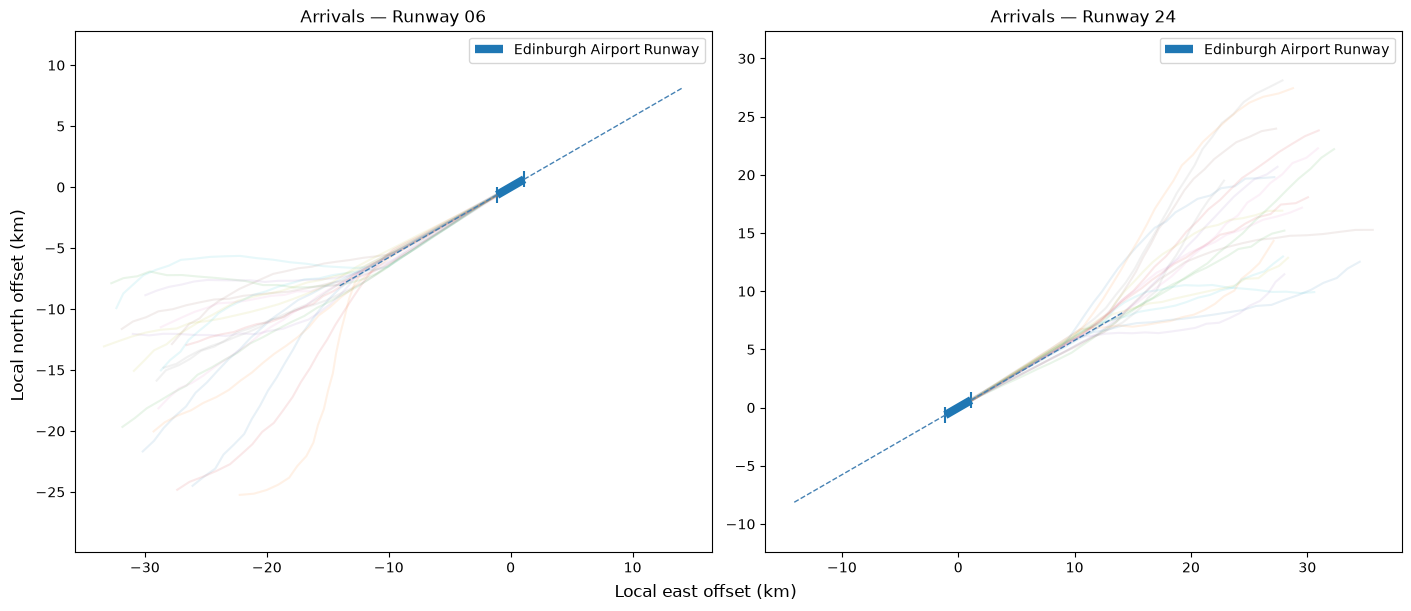

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

for ax, (runway_value, label) in zip(
    axes,
    [(0, "06"), (1, "24")],
):
    for traj in trajectories[runway == runway_value][20:40]:
        ax.plot(traj[:, 0], traj[:, 1], alpha=0.10)

    draw_edinburgh_runway(ax=ax, show_extended_final=True)
    ax.set_title(f"Arrivals — Runway {label}")
    ax.set_xlim(*AIRSPACE_XLIM)
    ax.set_ylim(*AIRSPACE_YLIM)
    ax.axis("equal")
    ax.legend()
fig.supxlabel("Local east offset (km)")
fig.supylabel("Local north offset (km)")
plt.show()


## 2. Make the approach geometry interpretable

The map view is visually useful, but a runway-aligned coordinate system is easier to interpret statistically.

For each point we calculate:

- **distance to landing threshold** along the runway centreline;
- **cross-track displacement** perpendicular to that centreline.

A realistic qualitative pattern is:

> large cross-track variation far from the airport → progressively small cross-track variation on final approach.


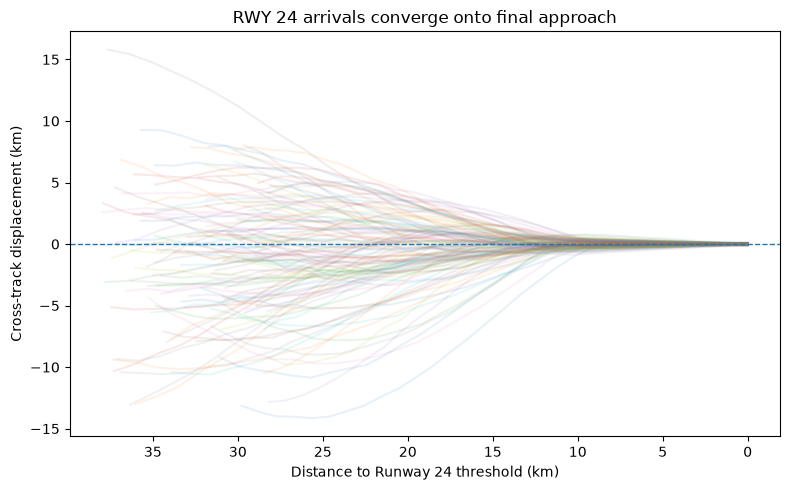

In [4]:
plt.figure(figsize=(8, 5))

for traj in trajectories[runway == 1][:120]:
    distance, cross = project_to_runway_coordinates(
        traj,
        runway_value=1,
    )
    plt.plot(distance, cross, alpha=0.10)

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.gca().invert_xaxis()

plt.xlabel("Distance to Runway 24 threshold (km)")
plt.ylabel("Cross-track displacement (km)")
plt.title("RWY 24 arrivals converge onto final approach")
plt.tight_layout()
plt.show()


## 3. Tokenise the local airspace

Transformers model discrete tokens.

We divide the East/North plotting region into a rectangular grid. Every waypoint `(x,y)` becomes one integer cell ID.

Two extra tokens represent the runway context:

- `<RWY06>`
- `<RWY24>`

A finer grid improves spatial precision but increases the size and difficulty of the categorical prediction problem.


In [5]:
NX = 60
NY = 60

N_POSITION_TOKENS = NX * NY

RWY06_TOKEN = N_POSITION_TOKENS
RWY24_TOKEN = N_POSITION_TOKENS + 1
INPUT_VOCAB_SIZE = N_POSITION_TOKENS + 2

x_edges = torch.linspace(AIRSPACE_XLIM[0], AIRSPACE_XLIM[1], NX + 1)
y_edges = torch.linspace(AIRSPACE_YLIM[0], AIRSPACE_YLIM[1], NY + 1)

x_centres = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centres = 0.5 * (y_edges[:-1] + y_edges[1:])

def xy_to_tokens(xy):
    x = xy[..., 0].clamp(AIRSPACE_XLIM[0], AIRSPACE_XLIM[1] - 1e-5)
    y = xy[..., 1].clamp(AIRSPACE_YLIM[0], AIRSPACE_YLIM[1] - 1e-5)

    ix = torch.bucketize(x, x_edges[1:-1])
    iy = torch.bucketize(y, y_edges[1:-1])

    return iy * NX + ix

def tokens_to_xy(tokens):
    iy = torch.div(tokens, NX, rounding_mode="floor")
    ix = tokens % NX

    return torch.stack(
        [x_centres[ix], y_centres[iy]],
        dim=-1,
    )

position_tokens = xy_to_tokens(trajectories)

print("Spatial grid:", NX, "x", NY)
print("Position-token vocabulary:", N_POSITION_TOKENS)
print("Tokenised dataset:", tuple(position_tokens.shape))


Spatial grid: 60 x 60
Position-token vocabulary: 3600
Tokenised dataset: (4000, 30)


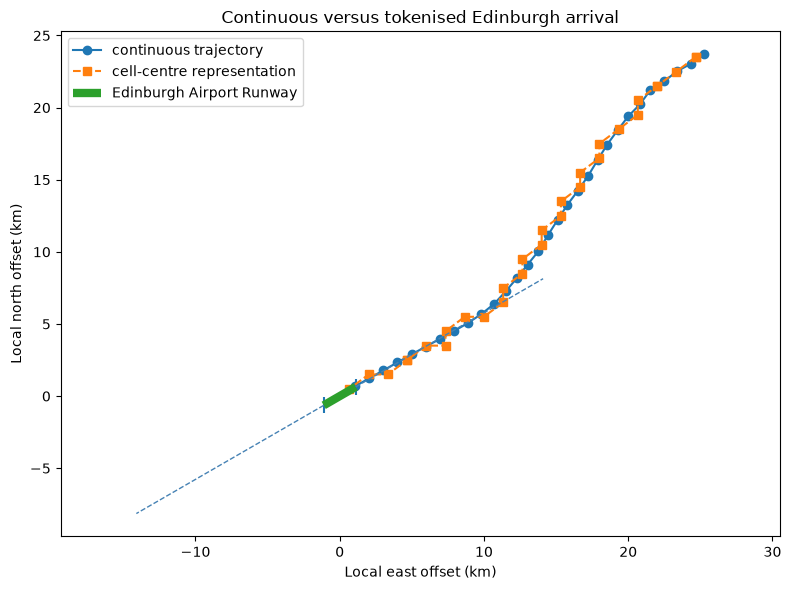

In [6]:
example_no = 7
quantised = tokens_to_xy(position_tokens[example_no])

plt.figure(figsize=(8, 6))
plt.plot(
    trajectories[example_no, :, 0],
    trajectories[example_no, :, 1],
    marker="o",
    label="continuous trajectory",
)
plt.plot(
    quantised[:, 0],
    quantised[:, 1],
    marker="s",
    linestyle="--",
    label="cell-centre representation",
)

draw_edinburgh_runway(show_extended_final=True)

plt.xlabel("Local east offset (km)")
plt.ylabel("Local north offset (km)")
plt.title("Continuous versus tokenised Edinburgh arrival")
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()


### YOUR TURN 1

Suppose we double `NX` and `NY`.

What improves, and what becomes harder?

Consider spatial quantisation error, vocabulary size, amount of data required and next-token uncertainty.


## 4. Build autoregressive input/target sequences

For a flight with tokens

$[X_1, X_2, \ldots, X_{30}]$,

the Transformer receives

$[\mathrm{RWY}, X_1, X_2, \ldots, X_{29}]$.

After discretising the local airspace into cells, the Transformer learns

$$\Pr(X_1,\ldots,X_{30} \mid \mathrm{RWY}) = \prod^{30}_{t=1}\Pr(s_t \mid \mathrm{RWY}, X_1,\ldots,X_{t-1})$$

The goal is to model a **distribution of plausible arrivals**, not a single average path.

In [7]:
n = len(trajectories)

perm = torch.randperm(
    n,
    generator=torch.Generator().manual_seed(SEED),
)

n_train = int(0.80 * n)
n_val = int(0.10 * n)

idx_train = perm[:n_train]
idx_val = perm[n_train:n_train + n_val]
idx_test = perm[n_train + n_val:]

def make_sequences(tokens, runway_label):
    context = torch.where(
        runway_label == 0,
        torch.tensor(RWY06_TOKEN),
        torch.tensor(RWY24_TOKEN),
    ).unsqueeze(1)

    full = torch.cat([context, tokens], dim=1)

    return full[:, :-1].long(), full[:, 1:].long()

train_inputs, train_targets = make_sequences(
    position_tokens[idx_train], runway[idx_train]
)
val_inputs, val_targets = make_sequences(
    position_tokens[idx_val], runway[idx_val]
)
test_inputs, test_targets = make_sequences(
    position_tokens[idx_test], runway[idx_test]
)

c_test = runway[idx_test]
traj_test = trajectories[idx_test]

BATCH_SIZE = 128

train_loader = DataLoader(
    TensorDataset(train_inputs, train_targets),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    TensorDataset(val_inputs, val_targets),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    TensorDataset(test_inputs, test_targets),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Input shape:", tuple(train_inputs.shape))
print("Target shape:", tuple(train_targets.shape))


Input shape: (3200, 30)
Target shape: (3200, 30)


## 5. Causal self-attention

When predicting waypoint 7, the model must not see waypoints 8–16.

A triangular causal mask blocks future information while still allowing all training positions to be evaluated in parallel.


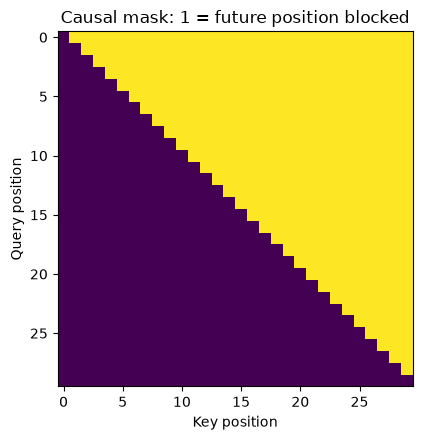

In [8]:
def causal_mask(length, device="cpu"):
    return torch.triu(
        torch.ones(length, length, dtype=torch.bool, device=device),
        diagonal=1,
    )

mask = causal_mask(N_WAYPOINTS)

plt.figure(figsize=(5, 4.5))
plt.imshow(mask.int(), interpolation="nearest")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.title("Causal mask: 1 = future position blocked")
plt.tight_layout()
plt.show()


## 6. Build a small Transformer

We use token embeddings, learned sequence-position embeddings, two Transformer blocks and a linear output head over the airspace-cell vocabulary.

The runway token is part of the prefix, so every subsequent location can depend on whether the aircraft is landing on Runway 06 or Runway 24.


In [9]:
class EdinburghArrivalTransformer(nn.Module):
    def __init__(
        self,
        input_vocab_size,
        output_vocab_size,
        max_seq_len,
        d_model=64,
        n_heads=4,
        n_layers=2,
        d_ff=64,
        dropout=0.10,
    ):
        super().__init__()

        self.token_embedding = nn.Embedding(input_vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_seq_len, d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            layer,
            num_layers=n_layers,
        )

        self.norm = nn.LayerNorm(d_model)
        self.output_head = nn.Linear(d_model, output_vocab_size)

    def forward(self, tokens):
        _, seq_len = tokens.shape

        positions = torch.arange(
            seq_len,
            device=tokens.device,
        )

        h = (
            self.token_embedding(tokens)
            + self.position_embedding(positions)[None, :, :]
        )

        h = self.transformer(
            h,
            mask=causal_mask(seq_len, tokens.device),
        )

        return self.output_head(self.norm(h))

model = EdinburghArrivalTransformer(
    input_vocab_size=INPUT_VOCAB_SIZE,
    output_vocab_size=N_POSITION_TOKENS,
    max_seq_len=N_WAYPOINTS,
).to(device)

print(
    "Trainable parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}",
)

batch_inputs, batch_targets = next(iter(train_loader))

with torch.inference_mode():
    logits = model(batch_inputs[:4].to(device))

print("Input:", tuple(batch_inputs[:4].shape))
print("Logits:", tuple(logits.shape))

assert logits.shape == (
    4,
    N_WAYPOINTS,
    N_POSITION_TOKENS,
)


Trainable parameters: 517,008
Input: (4, 30)
Logits: (4, 30, 3600)


## 7. Train by next-location likelihood

At each waypoint the model returns a categorical distribution over possible next cells.

Cross-entropy is the negative log-likelihood of the observed next location.


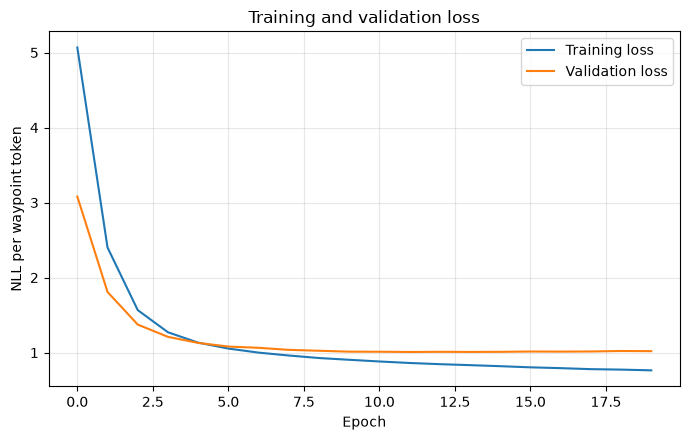

Final results:Epoch 20 | train NLL 0.763 | val NLL 1.019


In [ ]:
def evaluate_nll(model_to_evaluate, loader_to_evaluate):
    """Return the mean next-token negative log-likelihood."""
    model_to_evaluate.eval()

    evaluation_loss = 0.0
    evaluation_tokens = 0

    with torch.inference_mode():
        for batch_inputs, batch_targets in loader_to_evaluate:
            batch_inputs = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)

            batch_logits = model_to_evaluate(batch_inputs)

            batch_loss = F.cross_entropy(
                batch_logits.reshape(-1, N_POSITION_TOKENS),
                batch_targets.reshape(-1),
                reduction="sum"
            )

            evaluation_loss += batch_loss.item()
            evaluation_tokens += batch_targets.numel()

    return evaluation_loss / evaluation_tokens


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-3,
    weight_decay=1e-4,
)

N_EPOCHS = 20
history = {"train_nll": [], "val_nll": []}

figure, axis = plt.subplots(figsize=(7, 4.5))

for epoch in range(1, N_EPOCHS + 1):
    model.train()

    running_loss = 0.0
    running_tokens = 0

    for batch_inputs, batch_targets in train_loader:
        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)

        optimizer.zero_grad() #resetting gradients

        batch_logits = model(batch_inputs) #forward pass

        batch_loss = F.cross_entropy(
            batch_logits.reshape(-1, N_POSITION_TOKENS),
            batch_targets.reshape(-1),
        ) #compute loss

        batch_loss.backward() #backward pass
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step() #update parameters

        running_loss += batch_loss.item() * batch_targets.numel()
        running_tokens += batch_targets.numel()

    train_nll = running_loss / running_tokens
    val_nll = evaluate_nll(model, val_loader)

    history["train_nll"].append(train_nll)
    history["val_nll"].append(val_nll)

    axis.clear()
    axis.plot(history["train_nll"], label="Training loss")
    axis.plot(history["val_nll"], label="Validation loss")
    axis.set_xlabel("Epoch")
    axis.set_ylabel("NLL per waypoint token")
    axis.set_title("Training and validation loss")
    axis.legend()
    axis.grid(alpha=0.3)
    figure.tight_layout()

    clear_output(wait=True)
    display(figure)

    print(f"Epoch {epoch:02d} | ", f"train NLL {train_nll:.3f} | ",  f"val NLL {val_nll:.3f}")
clear_output(wait=True)
plt.show()
print("Final results:"
    f"Epoch {epoch:02d} | "
    f"train NLL {train_nll:.3f} | "
    f"val NLL {val_nll:.3f}"
)

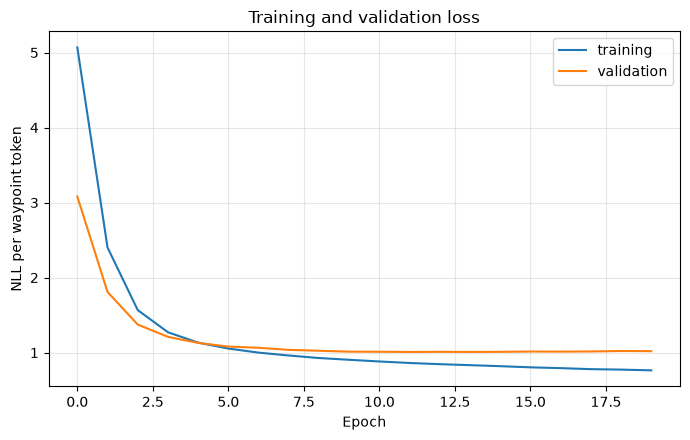

Test NLL per waypoint: 1.049
Test perplexity (exp(NLL)):       2.85


In [11]:
plt.figure(figsize=(7, 4.5))
plt.plot(history["train_nll"], label="training")
plt.plot(history["val_nll"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("NLL per waypoint token")
plt.title("Training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

test_nll = evaluate_nll(model, test_loader)

print(f"Test NLL per waypoint: {test_nll:.3f}")
print(f"Test perplexity (exp(NLL)):       {math.exp(test_nll):.2f}")


## 8. Generate new Edinburgh arrival trajectories

Generation starts with a runway token and proceeds one spatial token at a time.

Training evaluates positions in parallel, but generation is sequential because each sampled location becomes part of the next prefix.


In [12]:
def sample_from_logits(logits, temperature=1.0, top_k=None):
    if temperature <= 0:
        raise ValueError("temperature must be positive")

    logits = logits / temperature

    if top_k is not None:
        k = min(int(top_k), logits.shape[-1])
        values, indices = torch.topk(logits, k=k, dim=-1)

        filtered = torch.full_like(logits, -torch.inf)
        filtered.scatter_(1, indices, values)
        logits = filtered

    probabilities = torch.softmax(logits, dim=-1)

    return torch.multinomial(
        probabilities,
        num_samples=1,
    )

def generate_trajectory_tokens(
    model,
    n_samples,
    runway_value,
    temperature=0.8,
    top_k=5,
):
    model.eval()

    context_token = (
        RWY06_TOKEN if runway_value == 0
        else RWY24_TOKEN
    )

    sequence = torch.full(
        (n_samples, 1),
        context_token,
        dtype=torch.long,
        device=device,
    )

    with torch.inference_mode():
        for _ in range(N_WAYPOINTS):
            logits = model(sequence)

            next_token = sample_from_logits(
                logits[:, -1, :],
                temperature=temperature,
                top_k=top_k,
            )

            sequence = torch.cat(
                [sequence, next_token],
                dim=1,
            )

    return sequence[:, 1:].cpu()

generated_06 = tokens_to_xy(generate_trajectory_tokens(model, 300, runway_value=0))
generated_24 = tokens_to_xy(generate_trajectory_tokens(model, 300, runway_value=1))


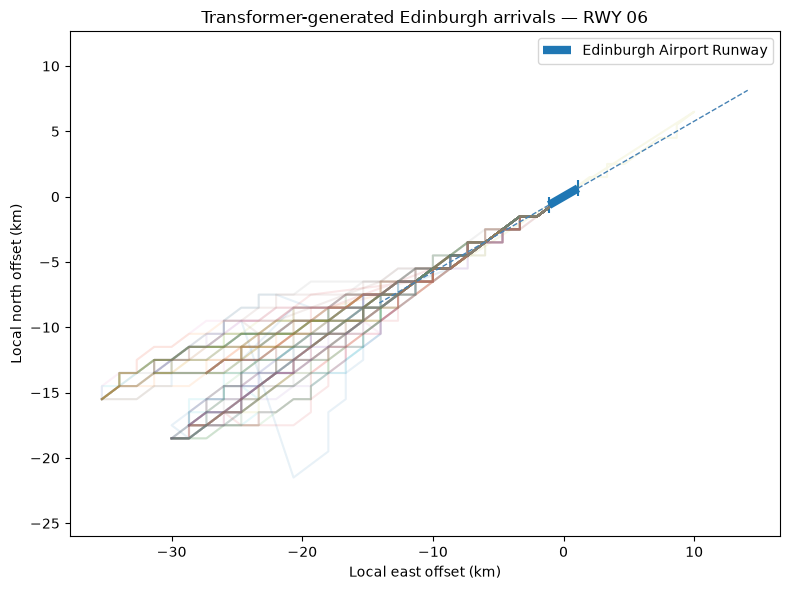

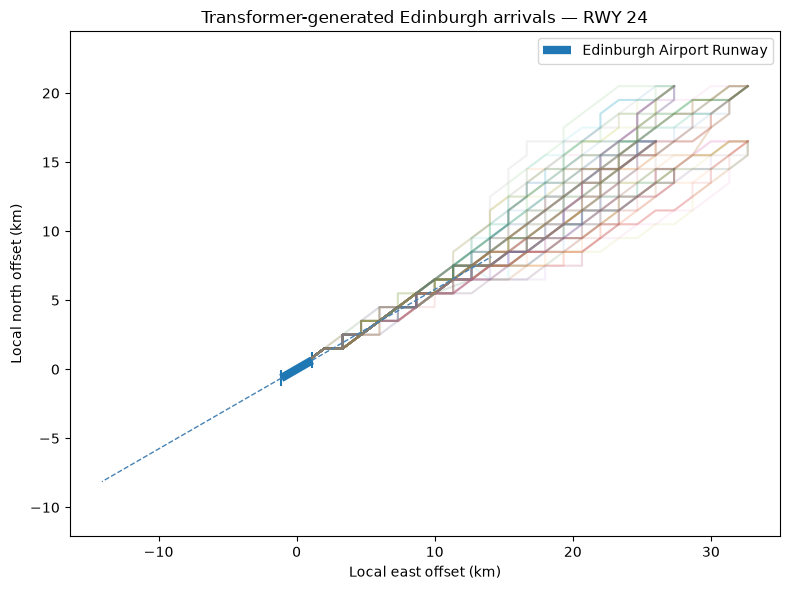

In [13]:
for generated, label in [
    (generated_06, "06"),
    (generated_24, "24"),
]:
    plt.figure(figsize=(8, 6))

    for traj in generated[:120]:
        plt.plot(traj[:, 0], traj[:, 1], alpha=0.10)

    draw_edinburgh_runway(show_extended_final=True)

    plt.xlabel("Local east offset (km)")
    plt.ylabel("Local north offset (km)")
    plt.title(f"Transformer-generated Edinburgh arrivals — RWY {label}")
    plt.xlim(*AIRSPACE_XLIM)
    plt.ylim(*AIRSPACE_YLIM)
    plt.axis("equal")
    plt.legend()
    plt.tight_layout()
    plt.show()


### YOUR TURN 2 — temperature and top-k

Try `temperature=0.5`, `temperature=1.2`, `top_k=5`, or `top_k=None`.

Look for too little diversity, large local jumps, or failure to converge smoothly toward the runway.


## 9. Geometric diagnostic: waypoint step length

A Transformer could assign good token likelihood while still occasionally making an aircraft “jump” between distant cells.

We compare distances between consecutive waypoints.


Observed mean step: 1.189 km
Generated mean step: 1.301 km
Generated trajectories entirely inside plot airspace: 100.0%


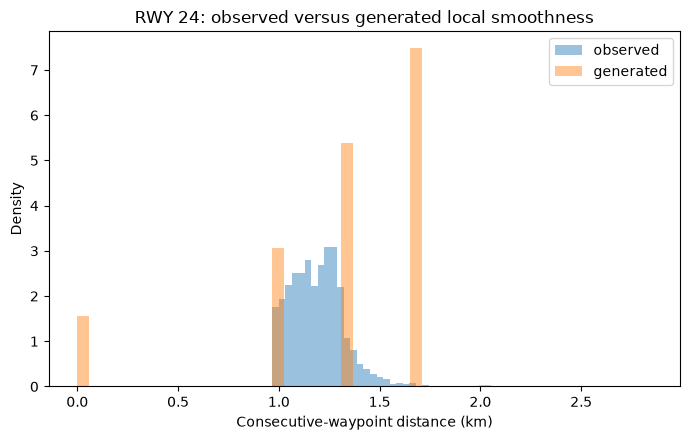

In [14]:
def step_lengths(xy):
    delta = xy[:, 1:, :] - xy[:, :-1, :]
    return torch.linalg.vector_norm(delta, dim=-1)
def fraction_inside_plot_airspace(xy):
    inside = (
        (xy[:, :, 0] >= AIRSPACE_XLIM[0])
        & (xy[:, :, 0] <= AIRSPACE_XLIM[1])
        & (xy[:, :, 1] >= AIRSPACE_YLIM[0])
        & (xy[:, :, 1] <= AIRSPACE_YLIM[1])
    )

    return inside.all(dim=1).float().mean()


observed_24 = traj_test[c_test == 1]

obs_steps = step_lengths(observed_24).flatten()
gen_steps = step_lengths(generated_24).flatten()

print("Observed mean step:", round(obs_steps.mean().item(), 3), "km")
print("Generated mean step:", round(gen_steps.mean().item(), 3), "km")
print("Generated trajectories entirely inside plot airspace:", f"{100 * fraction_inside_plot_airspace(generated_24).item():.1f}%")

plt.figure(figsize=(7, 4.5))
plt.hist(obs_steps.numpy(), bins=35, density=True, alpha=0.45, label="observed")
plt.hist(gen_steps.numpy(), bins=50, density=True, alpha=0.45, label="generated")
plt.xlabel("Consecutive-waypoint distance (km)")
plt.ylabel("Density")
plt.title("RWY 24: observed versus generated local smoothness")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Continue a partially observed arrival

Autoregressive models naturally support sequence completion.

We reveal the first four positions of a held-out Runway 24 flight and sample the remainder.

The continuation is a **sample from a conditional distribution**, not a deterministic forecast.


In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import numpy as np


def get_sampling_probabilities(
    logits,
    temperature=0.9,
    top_k=9,
):
    """
    Convert next-token logits into the probability distribution
    actually used for sampling.
    """
    if temperature <= 0:
        raise ValueError("temperature must be positive")

    logits = logits / temperature

    if top_k is not None:
        k = min(int(top_k), logits.shape[-1])

        values, indices = torch.topk(
            logits,
            k=k,
            dim=-1,
        )

        filtered_logits = torch.full_like(
            logits,
            -torch.inf,
        )

        filtered_logits.scatter_(
            1,
            indices,
            values,
        )

        logits = filtered_logits

    return torch.softmax(logits, dim=-1)


def complete_trajectory_with_probabilities(
    model,
    observed_prefix_xy,
    runway_value,
    temperature=0.75,
    top_k=20,
):
    """
    Complete a trajectory while recording the conditional
    probability distribution used at every generation step.
    """
    model.eval()

    prefix_tokens = xy_to_tokens(
        observed_prefix_xy
    ).long().to(device)

    context_token = (
        RWY06_TOKEN
        if runway_value == 0
        else RWY24_TOKEN
    )

    sequence = torch.cat(
        [
            torch.tensor(
                [context_token],
                dtype=torch.long,
                device=device,
            ),
            prefix_tokens,
        ]
    )[None, :]

    n_remaining = N_WAYPOINTS - len(prefix_tokens)

    probability_maps = []
    sampled_tokens = []

    with torch.inference_mode():

        for _ in range(n_remaining):

            # Predict the next spatial token
            logits = model(sequence)

            next_logits = logits[:, -1, :]

            # Distribution actually used for sampling
            probabilities = get_sampling_probabilities(
                next_logits,
                temperature=temperature,
                top_k=top_k,
            )

            # Store the spatial probability field
            probability_maps.append(
                probabilities[0]
                .reshape(NY, NX)
                .cpu()
            )

            # Sample one cell
            next_token = torch.multinomial(
                probabilities,
                num_samples=1,
            )

            sampled_tokens.append(
                next_token.item()
            )

            # Append sampled token to the sequence
            sequence = torch.cat(
                [sequence, next_token],
                dim=1,
            )

    completed_xy = tokens_to_xy(
        sequence[0, 1:].cpu()
    )

    return (
        completed_xy,
        probability_maps,
        sampled_tokens,
    )

# -----------------------------------------------------------
# Choose one held-out RWY 24 example
# -----------------------------------------------------------

example_idx = torch.where(c_test == 1)[0][7]
true_traj = traj_test[example_idx]

N_PREFIX = 7
prefix = true_traj[:N_PREFIX]

completion, probability_maps, sampled_tokens = (
    complete_trajectory_with_probabilities(
        model,
        prefix,
        runway_value=1,
        temperature=0.8,
        top_k=9,
    )
)


# -----------------------------------------------------------
# Compute a zoomed plotting window
# -----------------------------------------------------------

all_xy = torch.cat([true_traj, completion], dim=0).cpu().numpy()
x_min, y_min = all_xy.min(axis=0)
x_max, y_max = all_xy.max(axis=0)

pad_x = max(0.6, 0.15 * (x_max - x_min))
pad_y = max(0.6, 0.15 * (y_max - y_min))

xlim_zoom = (x_min - pad_x, x_max + pad_x)
ylim_zoom = (y_min - pad_y, y_max + pad_y)

In [31]:
from matplotlib.animation import FuncAnimation
from matplotlib import gridspec
from IPython.display import HTML, display
import matplotlib.pyplot as plt
import numpy as np


# -----------------------------------------------------------
# Helper: token index -> cell centre
# -----------------------------------------------------------

def token_to_cell_centre(token):
    iy = token // NX
    ix = token % NX
    return (x_centres[ix].item(), y_centres[iy].item(), ix, iy)

# -----------------------------------------------------------
# Global probability scale
# -----------------------------------------------------------

max_probability = max(p.max().item() for p in probability_maps)

# -----------------------------------------------------------
# Style
# -----------------------------------------------------------

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})


# -----------------------------------------------------------
# Layout
# -----------------------------------------------------------

fig = plt.figure(
    figsize=(14.5, 7.5),
    constrained_layout=True,
)
gs = fig.add_gridspec(
    nrows=2,
    ncols=3,
    width_ratios=[3.7, 0.18, 1.45],
    height_ratios=[0.55, 2.45],
)

ax_map = fig.add_subplot(gs[:, 0])
ax_cbar = fig.add_subplot(gs[1, 1])
ax_info = fig.add_subplot(gs[0, 2])
ax_side = fig.add_subplot(gs[1, 2])

fig.patch.set_facecolor("white")
ax_map.set_facecolor("#11151c")
ax_info.set_facecolor("#f7f8fa")
ax_side.set_facecolor("#f7f8fa")


# -----------------------------------------------------------
# Heatmap
# -----------------------------------------------------------

probability_image = ax_map.imshow(
    probability_maps[0].numpy(),
    origin="lower",
    extent=[
        AIRSPACE_XLIM[0],
        AIRSPACE_XLIM[1],
        AIRSPACE_YLIM[0],
        AIRSPACE_YLIM[1],
    ],
    interpolation="nearest",
    cmap="magma",
    vmin=0,
    vmax=max_probability,
    alpha=0.88,
    zorder=0,
)

cbar = fig.colorbar(
    probability_image,
    cax=ax_cbar,
)
cbar.set_label("Next cell conditional probability")


# -----------------------------------------------------------
# Static map content
# -----------------------------------------------------------

ax_map.plot(
    true_traj[:, 0],
    true_traj[:, 1],
    linestyle="--",
    linewidth=2.2,
    color="0.65",
    alpha=0.95,
    label="True trajectory",
    zorder=2,
)

ax_map.plot(
    prefix[:, 0],
    prefix[:, 1],
    marker="o",
    markersize=7,
    linewidth=2.8,
    color="#4ea3ff",
    label="Observed",
    zorder=4,
)

draw_edinburgh_runway(ax=ax_map, show_extended_final=True)


# -----------------------------------------------------------
# Animated artists
# -----------------------------------------------------------

generated_line, = ax_map.plot(
    [],
    [],
    linewidth=3.0,
    linestyle="-",
    marker="o",
    markersize=5.5,
    color="#ff4d4d",
    label="Generated continuation",
    zorder=5,
)

current_point = ax_map.scatter(
    [],
    [],
    s=135,
    marker="o",
    facecolor="#ffe66d",
    edgecolor="black",
    linewidth=1.4,
    zorder=6,
)

sampled_cell = ax_map.scatter(
    [],
    [],
    s=260,
    marker="s",
    facecolor="none",
    edgecolor="white",
    linewidth=2.2,
    zorder=7,
)


# -----------------------------------------------------------
# Map formatting
# -----------------------------------------------------------

ax_map.set_xlim(xlim_zoom)
ax_map.set_ylim(ylim_zoom)
ax_map.set_aspect("equal")
ax_map.grid(alpha=0.12, linewidth=0.9, color="white")

ax_map.set_xlabel("Local east offset (km)")
ax_map.set_ylabel("Local north offset (km)")
ax_map.set_title(
    "Autoregressive trajectory generation on a spatial grid",
    pad=16,
)

status_text = ax_map.text(
    0.02,
    0.98,
    "",
    transform=ax_map.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    color="white",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor=(0, 0, 0, 0.35),
        edgecolor=(1, 1, 1, 0.15),
    ),
)

leg = ax_map.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.86),
    frameon=True,
    fancybox=True,
)
leg.get_frame().set_alpha(0.9)


# -----------------------------------------------------------
# Info panel (top-right)
# -----------------------------------------------------------

ax_info.set_xticks([])
ax_info.set_yticks([])
for spine in ax_info.spines.values():
    spine.set_visible(False)

info_box = ax_info.text(
    0.03,
    0.90,
    "",
    ha="left",
    va="top",
    fontsize=11,
    transform=ax_info.transAxes,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="0.85",
    ),
)


# -----------------------------------------------------------
# Side panel (bottom-right)
# -----------------------------------------------------------

ax_side.set_title("Top candidate next cells", pad=10)
ax_side.set_xlabel("Probability")
ax_side.grid(axis="x", alpha=0.2)
ax_side.set_axisbelow(True)


# -----------------------------------------------------------
# Animation update
# -----------------------------------------------------------

def update(frame):

    probability_grid = probability_maps[frame]
    probability_image.set_data(probability_grid.numpy())

    # Generated trajectory up to current frame
    n_generated = frame + 1
    generated_xy = completion[:N_PREFIX + n_generated].cpu().numpy()

    generated_line.set_data(
        generated_xy[:, 0],
        generated_xy[:, 1],
    )

    current_xy = completion[N_PREFIX + frame].cpu().numpy()

    current_point.set_offsets(current_xy.reshape(1, 2))
    sampled_cell.set_offsets(current_xy.reshape(1, 2))

    # Current sampled token + probability
    flat = probability_grid.flatten()
    sampled_token = sampled_tokens[frame]
    sampled_prob = flat[sampled_token].item()

    waypoint_number = N_PREFIX + frame + 1

    status_text.set_text(
        f"Waypoint {waypoint_number}/{N_WAYPOINTS}\n"
        f"Sampled next-cell probability: {100*sampled_prob:.1f}%"
    )

    info_box.set_text(
        "Generation info\n\n"
        f"Observed prefix length: {N_PREFIX}\n"
        f"Current step: {frame + 1}/{len(probability_maps)}\n"
        f"Temperature: 0.75\n"
        f"Top-k: 20"
    )

    # Side bar chart
    ax_side.clear()
    ax_side.set_facecolor("#f7f8fa")
    ax_side.set_title("Top candidate next cells", pad=10)
    ax_side.set_xlabel("Probability")
    ax_side.grid(axis="x", alpha=0.2)
    ax_side.set_axisbelow(True)

    k_show = min(5, len(flat))
    topk = torch.topk(flat, k=k_show)

    top_probs = topk.values.cpu().numpy()
    top_tokens = topk.indices.cpu().numpy()

    labels = []
    for token in top_tokens:
        x_c, y_c, ix, iy = token_to_cell_centre(int(token))
        labels.append(f"({x_c:.2f}, {y_c:.2f})")

    y_pos = np.arange(k_show)

    bars = ax_side.barh(
        y_pos,
        top_probs,
        height=0.45,
    )

    ax_side.set_yticks(y_pos)
    ax_side.set_yticklabels(labels, fontsize=9)
    ax_side.invert_yaxis()
    ax_side.set_xlim(0, max(0.25, top_probs.max() * 1.18))

    # Highlight the sampled token if it is in the displayed list
    for i, token in enumerate(top_tokens):
        if int(token) == int(sampled_token):
            bars[i].set_edgecolor("black")
            bars[i].set_linewidth(1.6)

    for i, p in enumerate(top_probs):
        ax_side.text(
            p + 0.01 * ax_side.get_xlim()[1],
            i,
            f"{100*p:.1f}%",
            va="center",
            fontsize=9,
        )

    return (
        probability_image,
        generated_line,
        current_point,
        sampled_cell,
        status_text,
        info_box,
    )


# -----------------------------------------------------------
# Animate
# -----------------------------------------------------------

animation = FuncAnimation(
    fig,
    update,
    frames=len(probability_maps),
    interval=900,
    repeat=True,
    blit=False,
)

plt.close(fig)
display(HTML(animation.to_jshtml()))

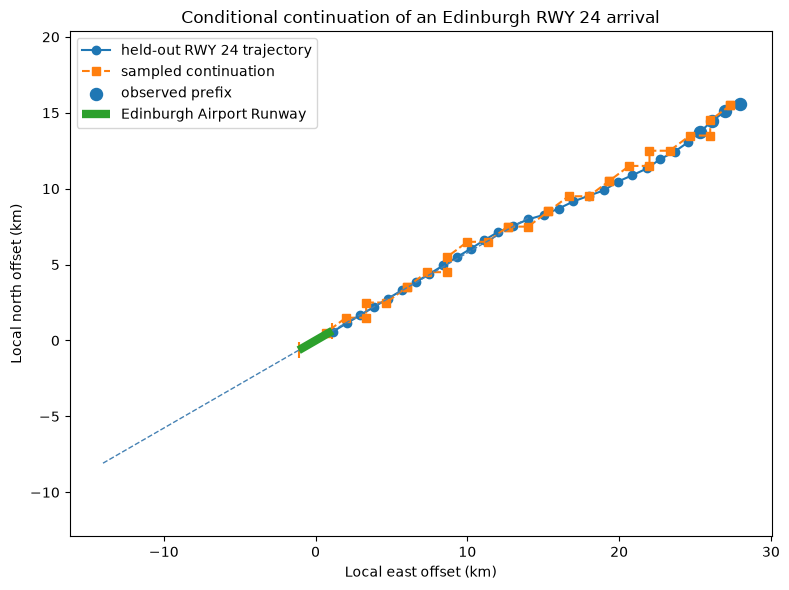

In [15]:
def complete_trajectory(
    model,
    observed_prefix_xy,
    runway_value,
    temperature=0.75,
    top_k=20,
):
    model.eval()

    prefix_tokens = xy_to_tokens(
        observed_prefix_xy
    ).long().to(device)

    context_token = (
        RWY06_TOKEN if runway_value == 0
        else RWY24_TOKEN
    )

    sequence = torch.cat(
        [
            torch.tensor(
                [context_token],
                dtype=torch.long,
                device=device,
            ),
            prefix_tokens,
        ]
    )[None, :]

    n_remaining = N_WAYPOINTS - len(prefix_tokens)

    with torch.inference_mode():
        for _ in range(n_remaining):
            logits = model(sequence)

            next_token = sample_from_logits(
                logits[:, -1, :],
                temperature=temperature,
                top_k=top_k,
            )

            sequence = torch.cat(
                [sequence, next_token],
                dim=1,
            )

    return tokens_to_xy(
        sequence[0, 1:].cpu()
    )

example_idx = torch.where(c_test == 1)[0][4]
true_traj = traj_test[example_idx]
prefix = true_traj[:4]

completion = complete_trajectory(
    model,
    prefix,
    runway_value=1,
)

plt.figure(figsize=(8, 6))
plt.plot(
    true_traj[:, 0],
    true_traj[:, 1],
    marker="o",
    label="held-out RWY 24 trajectory",
)
plt.plot(
    completion[:, 0],
    completion[:, 1],
    marker="s",
    linestyle="--",
    label="sampled continuation",
)
plt.scatter(
    prefix[:, 0],
    prefix[:, 1],
    s=75,
    label="observed prefix",
)

draw_edinburgh_runway(show_extended_final=True)

plt.xlabel("Local east offset (km)")
plt.ylabel("Local north offset (km)")
plt.title("Conditional continuation of an Edinburgh RWY 24 arrival")
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Save and reload

The spatial grid and runway-token definitions are part of the deployed representation, so they are saved alongside the neural-network weights.


In [16]:
checkpoint_path = Path(
    "gamex_edinburgh_arrival_transformer.pt"
)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_config": {
        "input_vocab_size": INPUT_VOCAB_SIZE,
        "output_vocab_size": N_POSITION_TOKENS,
        "max_seq_len": N_WAYPOINTS,
        "d_model": 48,
        "n_heads": 4,
        "n_layers": 2,
        "d_ff": 128,
        "dropout": 0.10,
    },
    "x_edges": x_edges,
    "y_edges": y_edges,
    "runway_tokens": {
        "06": RWY06_TOKEN,
        "24": RWY24_TOKEN,
    },
}

torch.save(checkpoint, checkpoint_path)

loaded = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False,
)

reloaded = EdinburghArrivalTransformer(
    **loaded["model_config"]
).to(device)

reloaded.load_state_dict(
    loaded["model_state_dict"]
)
reloaded.eval()

with torch.inference_mode():
    a = model(test_inputs[:4].to(device))
    b = reloaded(test_inputs[:4].to(device))

max_difference = (a - b).abs().max().item()

print(
    "Max prediction difference after reload:",
    f"{max_difference:.2e}",
)

assert max_difference < 1e-6


RuntimeError: Error(s) in loading state_dict for EdinburghArrivalTransformer:
	size mismatch for token_embedding.weight: copying a param with shape torch.Size([3602, 64]) from checkpoint, the shape in current model is torch.Size([3602, 48]).
	size mismatch for position_embedding.weight: copying a param with shape torch.Size([30, 64]) from checkpoint, the shape in current model is torch.Size([30, 48]).
	size mismatch for transformer.layers.0.self_attn.in_proj_weight: copying a param with shape torch.Size([192, 64]) from checkpoint, the shape in current model is torch.Size([144, 48]).
	size mismatch for transformer.layers.0.self_attn.in_proj_bias: copying a param with shape torch.Size([192]) from checkpoint, the shape in current model is torch.Size([144]).
	size mismatch for transformer.layers.0.self_attn.out_proj.weight: copying a param with shape torch.Size([64, 64]) from checkpoint, the shape in current model is torch.Size([48, 48]).
	size mismatch for transformer.layers.0.self_attn.o

## 12. Bridge to the normalising-flow notebook

The Transformer represents an Edinburgh arrival as a **discrete sequence of airspace cells**.

Notebook 3 keeps exactly the same trajectory continuous:

x = (x₁,y₁, …, x₁₆,y₁₆) ∈ ℝ³².

| Transformer | Normalising flow |
|---|---|
| spatial grid cells | continuous East/North coordinates |
| causal factorisation | change of variables |
| next-cell cross-entropy | exact continuous NLL |
| runway context token | runway-conditioned coupling networks |
| sequential sampling | inverse-flow sampling |
| prefix continuation is natural | density evaluation is natural |
